# Carga del dataset

In [2]:
import kagglehub

path = kagglehub.dataset_download("ninadaithal/imagesoasis")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/imagesoasis


In [3]:
import os
dataset_path = path + '/Data'

# List files in the dataset directory
non_demented_path = os.path.join(dataset_path, 'Non Demented')
moderate_demented_path = os.path.join(dataset_path, 'Moderate Dementia')
mild_demented_path = os.path.join(dataset_path, 'Mild Dementia')
very_mild_demented_path = os.path.join(dataset_path, 'Very mild Dementia')

non_demented_images = [os.path.join(non_demented_path, file) for file in os.listdir(non_demented_path) if file.endswith('.jpg')]
moderate_demented_images = [os.path.join(moderate_demented_path, file) for file in os.listdir(moderate_demented_path) if file.endswith('.jpg')]
mild_demented_images = [os.path.join(mild_demented_path, file) for file in os.listdir(mild_demented_path) if file.endswith('.jpg')]
very_mild_demented_images = [os.path.join(very_mild_demented_path, file) for file in os.listdir(very_mild_demented_path) if file.endswith('.jpg')]

from sklearn.model_selection import train_test_split
non_demented_train, non_demented_test = train_test_split(non_demented_images, test_size=0.2, random_state=42)
moderate_demented_train, moderate_demented_test = train_test_split(moderate_demented_images, test_size=0.2, random_state=42)
mild_demented_train, mild_demented_test = train_test_split(mild_demented_images, test_size=0.2, random_state=42)
very_mild_demented_train, very_mild_demented_test = train_test_split(very_mild_demented_images, test_size=0.2, random_state=42)

print(len(non_demented_train), len(moderate_demented_train), len(mild_demented_train), len(very_mild_demented_train))

import random
target_samples = 3000

moderate_demented_sample = random.choices(moderate_demented_train, k=target_samples)
mild_demented_sample = random.choices(mild_demented_train, k=target_samples)

very_mild_demented_sample = random.sample(very_mild_demented_train, target_samples)
non_demented_sample = random.sample(non_demented_train, target_samples)

print(len(non_demented_test), len(moderate_demented_test), len(mild_demented_test), len(very_mild_demented_test))

target_samples = 640
mild_demented_test = random.sample(mild_demented_test, target_samples)
non_demented_test = random.sample(non_demented_test, target_samples)
very_mild_demented_test = random.sample(very_mild_demented_test, target_samples)


53777 390 4001 10980
13445 98 1001 2745


In [4]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
encoder.fit([[0], [1], [2], [3]])

from PIL import Image
import numpy as np
data = []
result = []

for image in non_demented_sample:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data.append(img)
        result.append(encoder.transform([[0]]).toarray())

print("End 1")

for image in moderate_demented_sample:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data.append(img)
        result.append(encoder.transform([[1]]).toarray())

print("End 2")

for image in mild_demented_sample:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data.append(img)
        result.append(encoder.transform([[2]]).toarray())

print("End 3")

for image in very_mild_demented_sample:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data.append(img)
        result.append(encoder.transform([[3]]).toarray())

print("End 4")

data = np.array(data)

data = data/255.0

data.shape

result = np.array(result)
result = result.reshape((result.shape[0],4))
result.shape

X_train, x_val, y_train, y_val = train_test_split(data, result, test_size=0.2, random_state=42)


End 1
End 2
End 3
End 4


In [4]:
print(X_train.shape)

(9600, 128, 128, 3)


In [5]:
data_test = []
result_test = []

for image in non_demented_test:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data_test.append(img)
        result_test.append(encoder.transform([[0]]).toarray())

print("End 1")

for image in moderate_demented_test:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data_test.append(img)
        result_test.append(encoder.transform([[1]]).toarray())

print("End 2")

for image in mild_demented_test:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data_test.append(img)
        result_test.append(encoder.transform([[2]]).toarray())

print("End 3")

for image in very_mild_demented_test:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data_test.append(img)
        result_test.append(encoder.transform([[3]]).toarray())

print("End 4")

data_test = np.array(data_test)

data_test = data_test / 255.0

data_test.shape

result_test = np.array(result_test)
result_test = result_test.reshape((result_test.shape[0],4))
result_test.shape

X_test = data_test
y_test = result_test


End 1
End 2
End 3
End 4


# Creación de la red convolucional

## Funcion build para pasar al keras tuner para que pruebe con diferentes modelos.
En vez de utilizar las redes neuronales preentrenadas he querido probar a crear una red convolucional aplicándole un ajuste de los parámetros para ver que porcentaje de precisión conseguía con una red neuronal no tan densa como las redes preentrenadas.
La primera red convolucional tiene una cantidad de filtros de entre 16 y 64 y un kernel entre 3x3, 4x4 y 5x5
La segunda red convolucional tiene una cantidad de filtros de entre 32 y 128 y un kernel entre 3x3, 4x4 y 5x5
La penúltima capa densa tiene tiene una cantidad de neuronas entre 64 y 256.

Al igual que en el MLP Notebook, se define un callback para detener la ejecución si el validation loss no cambia.

In [6]:
import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow import keras
import keras_tuner as kt

def build(hp):
    model = keras.Sequential()
    model.add(keras.Input(shape=(128, 128, 3)))

    model.add(keras.layers.Conv2D(
        filters=hp.Int('conv1_filters', min_value=16, max_value=64, step=16),
        kernel_size=hp.Choice('conv1_kernel', values=[3,5]),
        activation='relu',
    ))
    model.add(keras.layers.MaxPooling2D(2,2))

    model.add(keras.layers.Conv2D(
        filters=hp.Int('conv2_filters', min_value=32, max_value=128, step=32),
        kernel_size=hp.Choice('conv2_kernel', values=[3,5]),
        activation='relu'
    ))
    model.add(keras.layers.MaxPooling2D(2,2))
    
    model.add(keras.layers.Flatten())

    model.add(keras.layers.Dense(
        units=hp.Int('dense_units', min_value=64, max_value=256, step=32),
        activation='relu'
    ))
    
    model.add(keras.layers.Dense(4, activation='softmax'))


    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

tuner = kt.RandomSearch(
    build,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='cnn_oasis'
)

early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

tuner.search(
    X_train, y_train,
    epochs=50,
    validation_data=(x_val, y_val),
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Trial 10 Complete [00h 01m 38s]
val_accuracy: 0.9837499856948853

Best val_accuracy So Far: 0.987500011920929
Total elapsed time: 00h 11m 57s


## Resultados en el conjunto de test

Mostramos el mejor modelo obtenido y lo probamos en el conjunto de test para ver la precisión. Tras ejecutar el modelo en el conjunto de pruebas, obtenemos una precisión del 97,92%, mayor que los modelos lineales y el perceptrón multicapa.

In [7]:

best_model = tuner.get_best_models(num_models=1)[0]

best_model.summary()

test_loss, test_accuracy = best_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 124, 124, 16)   │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 58, 58, 128)    │        51,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 107648)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    27,558,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,611,716 (105.33 MB)

 Trainable params: 27,611,716 (105.33 MB)

 Non-trainable params: 0 (0.00 B)


Test Accuracy: 0.9792
Test Loss: 0.1311


In [ ]:
H_best = best_model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(x_val, y_val),
    verbose=1
)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Precisión
plt.subplot(1, 2, 1)
plt.plot(H_best.history['accuracy'], label='Train Accuracy')
plt.plot(H_best.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy del mejor modelo')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(H_best.history['loss'], label='Train Loss')
plt.plot(H_best.history['val_loss'], label='Validation Loss')
plt.title('Loss del mejor modelo')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()

import datetime
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
plt.savefig(f"best_model_metrics_conv.png", dpi=300)

plt.show()

# Muestra de resultados

Al igual que con el MLP Notebook, mostramos imágenes con los resultados de las predicciones

64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


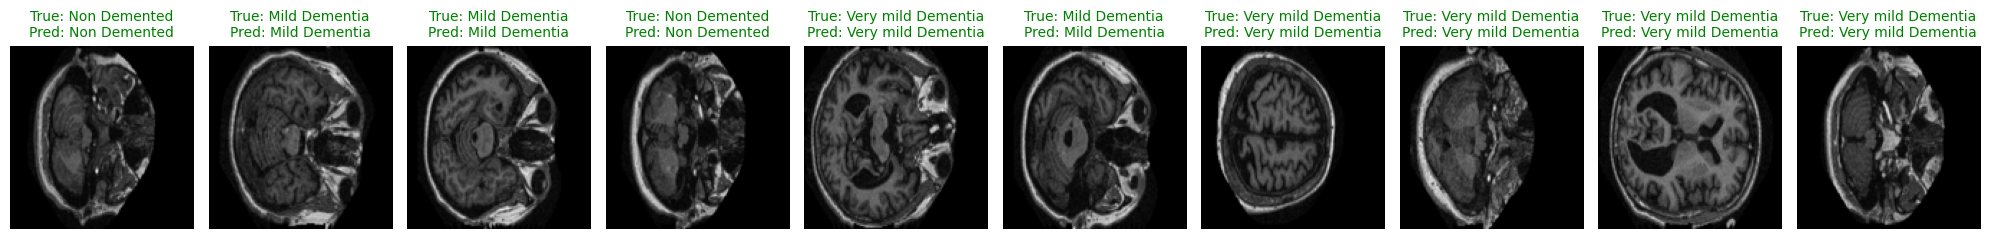

In [8]:
import matplotlib.pyplot as plt
import random
import numpy as np

y_pred_probs = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

class_names = ['Non Demented', 'Moderate Dementia', 'Mild Dementia', 'Very mild Dementia']

num_images_to_show = 10
random_indices = random.sample(range(len(X_test)), num_images_to_show)

plt.figure(figsize=(20, 4))
for i, idx in enumerate(random_indices):
    img = X_test[idx]
    true_label = y_true_classes[idx]
    predicted_label = y_pred_classes[idx]

    plt.subplot(1, num_images_to_show, i + 1)
    plt.imshow(img)
    plt.axis('off')

    color = "green" if true_label == predicted_label else "red"
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[predicted_label]}",
              fontsize=10, color=color)

    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

plt.tight_layout()
plt.savefig('predicciones_cnn.png', dpi=300, bbox_inches='tight')
plt.show()


Por último obtenemos una imágen del modelo para mostrar en el informe

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 124, 124, 16)   │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 58, 58, 128)    │        51,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 107648)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    27,558,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,611,716 (105.33 MB)

 Trainable params: 27,611,716 (105.33 MB)

 Non-trainable params: 0 (0.00 B)

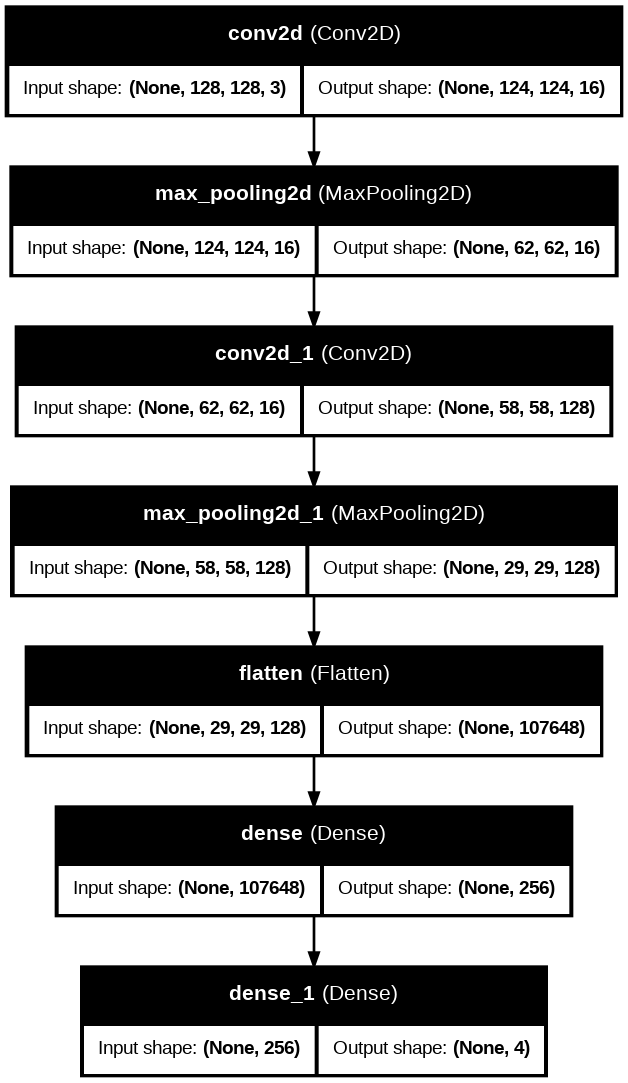

In [9]:
best_model.summary()

from tensorflow.keras.utils import plot_model

plot_model(best_model,
           to_file="/kaggle/working/best_model.png",
           show_shapes=True,
           show_layer_names=True,
           dpi=96)